# Experiment 6 — Feature Selection: AISO-Wrapper v2 on CICIDS2017

## 목적
Experiment 5 (Elliptic Bitcoin)에서 증명한 **Smart M + Score 방법론의 보편성 검증**.

- 다른 도메인: 금융 사기 탐지 → **네트워크 침입 탐지**
- 다른 데이터 구조: 165 피처 → **78 피처**
- 다른 불균형: 11.6% illicit → **19.7% attack (8개 공격 유형 혼재)**
- Multi-modal 공격 유형: DoS/Botnet/PortScan/DDoS/Web/FTP/SSH — 각기 다른 피처 조합이 유효

## 핵심 가설
> CICIDS2017처럼 공격 유형이 이질적인 환경에서,  
> MI 단독 랭킹은 가장 강한 DoS 신호에 편향되지만,  
> AISO Smart M은 여러 공격 유형에 보완적인 피처 조합을 동시에 탐색한다.

In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

np.random.seed(42)

DATA_DIR   = Path("CICIDS2017")
K_SELECT   = 15      # 78 피처 중 15개 선택 (~20%)
N_TYPES    = 12      # 클러스터 수
N_SEEDS    = 5
SEEDS      = [0, 7, 42, 77, 123]
GAMMA      = 0.5
SUBSAMPLE  = 80_000  # AISO 학습용 서브샘플 (전체 283만 행 중)

print(f"설정: K_SELECT={K_SELECT}, N_TYPES={N_TYPES}, SUBSAMPLE={SUBSAMPLE:,}")

설정: K_SELECT=15, N_TYPES=12, SUBSAMPLE=80,000


---
## 1. 데이터 로드 및 전처리

In [2]:
print("CICIDS2017 로딩 중...")
csv_files = sorted(DATA_DIR.glob("*.csv"))
dfs = []
for f in csv_files:
    df = pd.read_csv(f, low_memory=False)
    df.columns = df.columns.str.strip()
    dfs.append(df)
    print(f"  {f.name[:45]}: {len(df):,} rows")

df_all = pd.concat(dfs, ignore_index=True)
print(f"\n전체: {len(df_all):,} rows, {df_all.shape[1]} cols")

# 레이블 처리
label_col = [c for c in df_all.columns if 'label' in c.lower()][0]
df_all['label'] = (df_all[label_col].str.strip() != 'BENIGN').astype(int)
print(f"\n공격 유형 분포:")
for k, v in df_all[label_col].str.strip().value_counts().items():
    print(f"  {k:<40}: {v:>8} ({v/len(df_all):.2%})")

# 피처 컬럼
drop_cols = [label_col, 'label']
feat_cols = [c for c in df_all.columns if c not in drop_cols]

# NaN / Inf 제거
df_all[feat_cols] = df_all[feat_cols].apply(pd.to_numeric, errors='coerce')
df_all.replace([np.inf, -np.inf], np.nan, inplace=True)
before = len(df_all)
df_all.dropna(subset=feat_cols, inplace=True)
print(f"\nNaN/Inf 제거: {before:,} → {len(df_all):,} rows ({before-len(df_all):,} 제거)")

N_FEAT = len(feat_cols)
print(f"피처 수: {N_FEAT}")

# Train / Test split (stratified)
X_all = df_all[feat_cols].values.astype(float)
y_all = df_all['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, attack={y_train.sum():,} ({y_train.mean():.1%})")
print(f"Test:  {X_test.shape},  attack={y_test.sum():,}  ({y_test.mean():.1%})")

CICIDS2017 로딩 중...
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.: 225,745 rows
  Friday-WorkingHours-Afternoon-PortScan.pcap_I: 286,467 rows
  Friday-WorkingHours-Morning.pcap_ISCX.csv: 191,033 rows
  Monday-WorkingHours.pcap_ISCX.csv: 529,918 rows
  Thursday-WorkingHours-Afternoon-Infilteration: 288,602 rows
  Thursday-WorkingHours-Morning-WebAttacks.pcap: 170,366 rows
  Tuesday-WorkingHours.pcap_ISCX.csv: 445,909 rows
  Wednesday-workingHours.pcap_ISCX.csv: 692,703 rows

전체: 2,830,743 rows, 79 cols

공격 유형 분포:
  BENIGN                                  :  2273097 (80.30%)
  DoS Hulk                                :   231073 (8.16%)
  PortScan                                :   158930 (5.61%)
  DDoS                                    :   128027 (4.52%)
  DoS GoldenEye                           :    10293 (0.36%)
  FTP-Patator                             :     7938 (0.28%)
  SSH-Patator                             :     5897 (0.21%)
  DoS slowloris                           :     5796 

---
## 2. Smart M 구성

In [3]:

# ── Stratified 30K 서브샘플 (공격 클래스 비율 보존) ─────────────
rng0   = np.random.RandomState(42)
n_sub  = min(30_000, len(X_train))
pos_idx = np.where(y_train == 1)[0]
neg_idx = np.where(y_train == 0)[0]
n_pos   = int(n_sub * y_train.mean())
n_neg   = n_sub - n_pos
sub_pos = rng0.choice(pos_idx, min(n_pos, len(pos_idx)), replace=False)
sub_neg = rng0.choice(neg_idx, min(n_neg, len(neg_idx)), replace=False)
sub_idx = np.concatenate([sub_pos, sub_neg])
rng0.shuffle(sub_idx)

X_sub_clust = X_train[sub_idx]
y_sub_clust = y_train[sub_idx]
print(f"클러스터링 서브샘플: {len(sub_idx):,}개  "
      f"(attack={y_sub_clust.mean():.1%} — train 비율 {y_train.mean():.1%}와 비교)")

print("피처 클러스터링 중...")
C     = np.corrcoef(X_sub_clust.T)
C_abs = np.abs(np.nan_to_num(C, nan=0.0))
dist_matrix = 1.0 - C_abs
np.fill_diagonal(dist_matrix, 0.0)
dist_matrix = np.clip(dist_matrix, 0.0, None)

clustering = AgglomerativeClustering(
    n_clusters=N_TYPES, metric='precomputed', linkage='average'
)
cluster_labels = clustering.fit_predict(dist_matrix)
print(f"클러스터 크기: {sorted(np.bincount(cluster_labels).tolist())}")

print("MI 계산 중...")
MI_global = mutual_info_classif(X_sub_clust, y_sub_clust, random_state=42)
print(f"MI range: [{MI_global.min():.4f}, {MI_global.max():.4f}]")


def build_M(mode='smart'):
    K = N_TYPES
    M = np.zeros((K, K))
    mean_MI = np.array([
        MI_global[cluster_labels == k].mean()
        if (cluster_labels == k).any() else 0.0
        for k in range(K)
    ])
    MI_norm = (mean_MI - mean_MI.min()) / (mean_MI.max() - mean_MI.min() + 1e-8)

    for i in range(K):
        for j in range(K):
            fi = np.where(cluster_labels == i)[0]
            fj = np.where(cluster_labels == j)[0]
            if i == j:
                M[i][j] = -1.0
            else:
                corr_pen = -np.mean(C_abs[np.ix_(fi, fj)])
                if mode == 'smart':
                    M[i][j] = corr_pen + GAMMA * (MI_norm[j] - MI_norm[i])
                else:
                    M[i][j] = corr_pen
    return M


M_smart = build_M('smart')
print(f"\nM_smart 비대칭 확인: M[0,1]={M_smart[0,1]:.3f}, M[1,0]={M_smart[1,0]:.3f}  "
      f"(차이={M_smart[0,1]-M_smart[1,0]:+.3f})")


클러스터링 서브샘플: 30,000개  (attack=19.7% — train 비율 19.7%와 비교)
피처 클러스터링 중...
클러스터 크기: [1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 65]
MI 계산 중...
MI range: [0.0000, 0.3336]

M_smart 비대칭 확인: M[0,1]=-0.506, M[1,0]=0.494  (차이=-1.000)


---
## 3. 비교 방법 (결정론적 필터/래퍼)

In [4]:
def select_mi(X, y, k, seed=42):
    mi = mutual_info_classif(X, y, random_state=seed)
    return np.argsort(mi)[::-1][:k]


def select_lasso(X, y, k):
    for C_val in [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]:
        lr = LogisticRegression(
            penalty='l1', solver='liblinear', C=C_val,
            class_weight='balanced', random_state=42, max_iter=300
        )
        lr.fit(X, y)
        nonzero = np.where(lr.coef_[0] != 0)[0]
        if len(nonzero) >= k:
            return np.argsort(np.abs(lr.coef_[0]))[::-1][:k]
    lr = LogisticRegression(penalty='l1', solver='liblinear', C=1.0,
                            class_weight='balanced', random_state=42, max_iter=300)
    lr.fit(X, y)
    return np.argsort(np.abs(lr.coef_[0]))[::-1][:k]


def select_mrmr(X, y, k, seed=42):
    mi = mutual_info_classif(X, y, random_state=seed)
    C_abs_loc = np.abs(np.corrcoef(X.T))
    np.fill_diagonal(C_abs_loc, 0.0)
    selected  = [int(np.argmax(mi))]
    remaining = list(range(X.shape[1]))
    remaining.remove(selected[0])
    while len(selected) < k:
        scores = [mi[f] - float(np.mean(C_abs_loc[f, selected])) for f in remaining]
        best   = remaining[int(np.argmax(scores))]
        selected.append(best); remaining.remove(best)
    return np.array(selected)


def evaluate(X_tr, y_tr, X_te, y_te, feat_idx, seed=42):
    lr = LogisticRegression(
        class_weight='balanced', max_iter=500, random_state=seed, C=1.0
    )
    lr.fit(X_tr[:, feat_idx], y_tr)
    proba = lr.predict_proba(X_te[:, feat_idx])[:, 1]
    pred  = lr.predict(X_te[:, feat_idx])
    return {
        "AUC":    roc_auc_score(y_te, proba),
        "PR-AUC": average_precision_score(y_te, proba),
        "F1":     f1_score(y_te, pred),
    }

print("비교 방법 함수 정의 완료")

비교 방법 함수 정의 완료


---
## 4. AISO Wrapper v2 (Exp5와 동일)

In [5]:

class AISOwrapper:
    def __init__(self, n_agents=20, n_iter=80, beta=0.15,
                 subsample_ratio=0.15, val_ratio=0.2,
                 T_start=1.0, T_end=0.05, monitor_div=True):
        self.n_agents        = n_agents
        self.n_iter          = n_iter
        self.beta            = beta
        self.subsample_ratio = subsample_ratio
        self.val_ratio       = val_ratio
        self.T_start         = T_start
        self.T_end           = T_end
        self.monitor_div     = monitor_div  # W 다양성 모니터링

    def select(self, X, y, cluster_labels, K_select, M, seed=42):
        rng  = np.random.RandomState(seed)
        N, D = X.shape
        K    = M.shape[0]
        nb   = min(3, self.n_agents - 1)

        val_n   = int(self.val_ratio * N)
        val_idx = rng.choice(N, val_n, replace=False)
        tr_mask = np.ones(N, bool); tr_mask[val_idx] = False
        X_val, y_val = X[val_idx],  y[val_idx]
        X_t,   y_t   = X[tr_mask],  y[tr_mask]

        proxy = SGDClassifier(
            loss='log_loss', max_iter=5, tol=None,
            class_weight='balanced', random_state=seed
        )
        cache   = {}
        n_calls = [0]
        sub_n   = max(50, int(self.subsample_ratio * len(X_t)))

        # ── 온도 스케줄 사전 계산 ─────────────────────────────
        temps = [
            self.T_start * ((self.T_end / self.T_start) ** (t / max(1, self.n_iter - 1)))
            for t in range(self.n_iter)
        ]

        def get_mask(Wi, t, explore=True):
            if explore:
                T      = temps[t]
                logits = Wi[cluster_labels] / T
                logits -= logits.max()
                probs  = np.exp(logits); probs /= probs.sum()
                return tuple(rng.choice(D, K_select, replace=False, p=probs))
            else:
                return tuple(np.argsort(Wi[cluster_labels])[-K_select:])

        def get_score(mask_key, X_sub, y_sub):
            n_calls[0] += 1
            if mask_key in cache:
                return cache[mask_key]
            feat = list(mask_key)
            try:
                proxy.fit(X_sub[:, feat], y_sub)
                proba = proxy.predict_proba(X_val[:, feat])[:, 1]
                s = roc_auc_score(y_val, proba)
            except Exception:
                s = 0.5
            cache[mask_key] = s
            return s

        # ── W 다양성: 평균 엔트로피 계산 함수 ─────────────────
        def w_entropy(W):
            eps = 1e-10
            return float(np.mean(-np.sum(W * np.log(W + eps), axis=1)))

        W      = rng.dirichlet(np.ones(K), self.n_agents)
        scores = np.zeros(self.n_agents)
        for i in range(self.n_agents):
            sub = rng.choice(len(X_t), sub_n, replace=False)
            scores[i] = get_score(get_mask(W[i], 0), X_t[sub], y_t[sub])

        div_log = []  # (iter, T, W_entropy) 기록

        for t in range(self.n_iter):
            Cm = W @ M @ W.T
            np.fill_diagonal(Cm, 0.0)
            sub = rng.choice(len(X_t), sub_n, replace=False)
            X_sub, y_sub = X_t[sub], y_t[sub]

            for i in range(self.n_agents):
                att = np.argsort(Cm[i])[-nb:]
                att_scores = np.array([
                    get_score(get_mask(W[j], t), X_sub, y_sub) for j in att
                ])
                max_s = att_scores.max() + 1e-8
                bj    = att[np.argmax(Cm[i, att] * att_scores / max_s)]
                W_new  = (1 - self.beta) * W[i] + self.beta * W[bj]
                W[i]   = W_new / W_new.sum()
                scores[i] = get_score(get_mask(W[i], t), X_sub, y_sub)

            # 20 iter마다 다양성 기록
            if self.monitor_div and t % 20 == 0:
                ent = w_entropy(W)
                div_log.append((t, temps[t], ent))

        if self.monitor_div and div_log:
            print(f"    [seed={seed}] W 다양성(entropy): " +
                  "  ".join([f"t={t}: T={T:.3f} H={H:.3f}" for t, T, H in div_log]))

        final_lr = LogisticRegression(
            solver='liblinear', C=1.0, max_iter=500,
            class_weight='balanced', random_state=seed
        )
        fseen, final_scores = {}, []
        for i in range(self.n_agents):
            mk   = get_mask(W[i], self.n_iter - 1, explore=False)
            feat = list(mk)
            if mk not in fseen:
                final_lr.fit(X_t[:, feat], y_t)
                proba     = final_lr.predict_proba(X_val[:, feat])[:, 1]
                fseen[mk] = roc_auc_score(y_val, proba)
            final_scores.append(fseen[mk])

        best_mask = np.array(list(
            get_mask(W[np.argmax(final_scores)], self.n_iter - 1, explore=False)
        ))
        hit_rate = 1.0 - len(cache) / max(1, n_calls[0])
        return best_mask, {'cache_size': len(cache), 'calls': n_calls[0],
                           'hit_rate': hit_rate, 'div_log': div_log}


wrapper = AISOwrapper(n_agents=20, n_iter=80, beta=0.15,
                      T_start=1.0, T_end=0.05, monitor_div=True)
print("AISOwrapper 정의 완료  (stratified subsample, W entropy 모니터링 추가)")
print(f"온도 스케줄 확인: T_start=1.0 → T_end=0.05")
print(f"  t=0:  T={1.0:.3f}  t=20: T={1.0*(0.05/1.0)**(20/79):.3f}  "
      f"t=40: T={1.0*(0.05/1.0)**(40/79):.3f}  t=79: T={0.05:.3f}")


AISOwrapper 정의 완료  (stratified subsample, W entropy 모니터링 추가)
온도 스케줄 확인: T_start=1.0 → T_end=0.05
  t=0:  T=1.000  t=20: T=0.468  t=40: T=0.219  t=79: T=0.050


---
## 5. 전체 실험 실행

AISO 학습 데이터: 전체 Train에서 `SUBSAMPLE`개 무작위 추출 (속도 제어)

In [6]:
# AISO 학습용 서브샘플 (결정론적 방법은 전체 사용)
rng_sub = np.random.RandomState(42)
sub_idx_aiso = rng_sub.choice(len(X_train), min(SUBSAMPLE, len(X_train)), replace=False)
X_aiso = X_train[sub_idx_aiso]
y_aiso = y_train[sub_idx_aiso]
print(f"AISO 학습 데이터: {X_aiso.shape}, attack={y_aiso.mean():.1%}")

# MI도 서브샘플로 계산 (전체 사용 시 수분 소요)
MI_eval = mutual_info_classif(X_aiso, y_aiso, random_state=42)

all_results = {}
all_masks   = {}

# ── 결정론적 방법 ─────────────────────────────────────────────
det_methods = {
    f"All ({N_FEAT})": np.arange(N_FEAT),
    "Mutual Info":     np.argsort(MI_eval)[::-1][:K_SELECT],
    "LASSO":           select_lasso(X_aiso, y_aiso, K_SELECT),
    "mRMR":            select_mrmr(X_aiso, y_aiso, K_SELECT),
}

print("\n결정론적 방법 실행 중...")
for name, idx in det_methods.items():
    res = evaluate(X_train, y_train, X_test, y_test, idx)
    all_results[name] = [res]
    print(f"  {name:<16}: AUC={res['AUC']:.4f}  PR-AUC={res['PR-AUC']:.4f}  F1={res['F1']:.4f}")

# ── AISO Wrapper (5 seeds × 2 M 설정) ────────────────────────
print("\nAISO Wrapper 실험 중 (5 seeds × 2)...")
aiso_configs = {
    "AISO (Rand+Score)":  'random',
    "AISO (Smart+Score)": M_smart,
}

for name, M_cfg in aiso_configs.items():
    all_results[name] = []
    all_masks[name]   = []
    for seed in SEEDS:
        M_use = (
            np.random.RandomState(seed).uniform(-0.5, 2.0, (N_TYPES, N_TYPES))
            if isinstance(M_cfg, str) else M_cfg
        )
        idx, info = wrapper.select(X_aiso, y_aiso, cluster_labels, K_SELECT, M_use, seed=seed)
        all_masks[name].append(idx)
        res = evaluate(X_train, y_train, X_test, y_test, idx, seed=seed)
        res['seed'] = seed
        all_results[name].append(res)
        print(f"  {name} seed={seed}: AUC={res['AUC']:.4f}  "
              f"PR-AUC={res['PR-AUC']:.4f}  F1={res['F1']:.4f}  cache_hit={info['hit_rate']:.1%}")

print("\n완료")

AISO 학습 데이터: (80000, 78), attack=19.6%


c:\Users\kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



결정론적 방법 실행 중...
  All (78)        : AUC=0.9791  PR-AUC=0.9194  F1=0.8188
  Mutual Info     : AUC=0.9517  PR-AUC=0.8570  F1=0.7496
  LASSO           : AUC=0.9707  PR-AUC=0.9010  F1=0.7591
  mRMR            : AUC=0.9259  PR-AUC=0.7801  F1=0.6868

AISO Wrapper 실험 중 (5 seeds × 2)...
    [seed=0] W 다양성(entropy): t=0: T=1.000 H=2.184  t=20: T=0.468 H=2.295  t=40: T=0.219 H=2.277  t=60: T=0.103 H=2.276
  AISO (Rand+Score) seed=0: AUC=0.7537  PR-AUC=0.5168  F1=0.4535  cache_hit=0.0%
    [seed=7] W 다양성(entropy): t=0: T=1.000 H=2.206  t=20: T=0.468 H=2.394  t=40: T=0.219 H=2.387  t=60: T=0.103 H=2.387
  AISO (Rand+Score) seed=7: AUC=0.7579  PR-AUC=0.5219  F1=0.4681  cache_hit=0.0%
    [seed=42] W 다양성(entropy): t=0: T=1.000 H=2.208  t=20: T=0.468 H=2.370  t=40: T=0.219 H=2.360  t=60: T=0.103 H=2.359
  AISO (Rand+Score) seed=42: AUC=0.7579  PR-AUC=0.5219  F1=0.4681  cache_hit=0.0%
    [seed=77] W 다양성(entropy): t=0: T=1.000 H=2.197  t=20: T=0.468 H=2.374  t=40: T=0.219 H=2.356  t=60: T=0.103 H=2.3

---
## 6. 결과 요약

In [7]:
METHOD_ORDER = [
    f"All ({N_FEAT})", "Mutual Info", "LASSO", "mRMR",
    "AISO (Rand+Score)", "AISO (Smart+Score)",
]

print(f"{'Method':<24} {'AUC mean':>9} {'AUC std':>9} {'PR-AUC':>9} {'PR std':>8}")
print("-" * 66)

summary = {}
for m in METHOD_ORDER:
    aucs   = [r['AUC']    for r in all_results[m]]
    praucs = [r['PR-AUC'] for r in all_results[m]]
    std_a  = np.std(aucs)   if len(aucs)  > 1 else 0
    std_p  = np.std(praucs) if len(praucs) > 1 else 0
    summary[m] = {'AUC_mean': np.mean(aucs), 'AUC_std': std_a,
                  'PRAUC_mean': np.mean(praucs), 'PRAUC_std': std_p}
    std_str = f"{std_a:.4f}" if std_a > 0 else "   N/A"
    pstd_str = f"{std_p:.4f}" if std_p > 0 else "  N/A"
    print(f"  {m:<22} {np.mean(aucs):>9.4f} {std_str:>9} {np.mean(praucs):>9.4f} {pstd_str:>8}")

print("-" * 66)
r_smart = summary["AISO (Smart+Score)"]
r_rand  = summary["AISO (Rand+Score)"]
r_mrmr  = summary["mRMR"]
print(f"\nvs mRMR:  Smart+Score PR-AUC {r_smart['PRAUC_mean']:.4f} vs mRMR {r_mrmr['PRAUC_mean']:.4f}  "
      f"(Δ={r_smart['PRAUC_mean']-r_mrmr['PRAUC_mean']:+.4f})")
print(f"Smart vs Rand: {r_smart['PRAUC_mean']:.4f} vs {r_rand['PRAUC_mean']:.4f}  "
      f"(Δ={r_smart['PRAUC_mean']-r_rand['PRAUC_mean']:+.4f})")

Method                    AUC mean   AUC std    PR-AUC   PR std
------------------------------------------------------------------
  All (78)                  0.9791       N/A    0.9194      N/A
  Mutual Info               0.9517       N/A    0.8570      N/A
  LASSO                     0.9707       N/A    0.9010      N/A
  mRMR                      0.9259       N/A    0.7801      N/A
  AISO (Rand+Score)         0.7807    0.0490    0.5450   0.0498
  AISO (Smart+Score)        0.8786    0.0000    0.6445      N/A
------------------------------------------------------------------

vs mRMR:  Smart+Score PR-AUC 0.6445 vs mRMR 0.7801  (Δ=-0.1357)
Smart vs Rand: 0.6445 vs 0.5450  (Δ=+0.0995)


---
## 7. Stability Selection + MI 검증

In [8]:
# ── 피처별 선택 빈도 ──────────────────────────────────────────
freq_smart = np.zeros(N_FEAT, dtype=int)
for mask in all_masks["AISO (Smart+Score)"]:
    freq_smart[list(mask)] += 1

print("Smart+Score 피처 선택 빈도 분포:")
for thr in [5, 4, 3, 2, 1]:
    print(f"  freq >= {thr}: {np.sum(freq_smart >= thr):3d} 피처")

stable_smart = np.where(freq_smart >= 3)[0]
top_by_freq  = np.argsort(freq_smart)[::-1][:K_SELECT]
print(f"\n[Smart] freq>=3 피처 수: {len(stable_smart)}")

for label, idx in [
    (f"Stability (>=3, n={len(stable_smart)})", stable_smart),
    (f"Top-{K_SELECT} by Freq",                 top_by_freq),
]:
    if len(idx) == 0:
        print(f"{label}: 피처 없음")
        continue
    res = evaluate(X_train, y_train, X_test, y_test, idx)
    print(f"\n{label}:")
    print(f"  PR-AUC={res['PR-AUC']:.4f}  F1={res['F1']:.4f}  AUC={res['AUC']:.4f}")
    print(f"  (mRMR: {r_mrmr['PRAUC_mean']:.4f}, Smart mean: {r_smart['PRAUC_mean']:.4f})")

# ── MI top-K 검증 ─────────────────────────────────────────────
print("\n=== MI top-K 검증 ===")
if len(stable_smart) > 0:
    print(f"Stability 피처 인덱스: {stable_smart.tolist()}")
    print(f"Stability 피처 MI 값:  {[round(v, 4) for v in MI_eval[stable_smart].tolist()]}")

    mi_topk = np.argsort(MI_eval)[::-1][:len(stable_smart)]
    print(f"MI top-{len(stable_smart)} 인덱스: {mi_topk.tolist()}")
    print(f"MI top-{len(stable_smart)} MI 값:  {[round(v, 4) for v in MI_eval[mi_topk].tolist()]}")

    overlap = set(stable_smart.tolist()) & set(mi_topk.tolist())
    print(f"인덱스 겹침: {sorted(overlap)}  ({len(overlap)}/{len(stable_smart)} 일치)")

    res_mi = evaluate(X_train, y_train, X_test, y_test, mi_topk)
    print(f"\nMI top-{len(stable_smart)} PR-AUC: {res_mi['PR-AUC']:.4f}")
    if len(stable_smart) > 0:
        res_stab = evaluate(X_train, y_train, X_test, y_test, stable_smart)
        print(f"Stability   PR-AUC: {res_stab['PR-AUC']:.4f}")
        print(f"차이: {res_stab['PR-AUC'] - res_mi['PR-AUC']:+.4f}")

Smart+Score 피처 선택 빈도 분포:
  freq >= 5:  15 피처
  freq >= 4:  15 피처
  freq >= 3:  15 피처
  freq >= 2:  15 피처
  freq >= 1:  15 피처

[Smart] freq>=3 피처 수: 15

Stability (>=3, n=15):
  PR-AUC=0.6445  F1=0.5540  AUC=0.8786
  (mRMR: 0.7801, Smart mean: 0.6445)

Top-15 by Freq:
  PR-AUC=0.6439  F1=0.5286  AUC=0.8799
  (mRMR: 0.7801, Smart mean: 0.6445)

=== MI top-K 검증 ===
Stability 피처 인덱스: [63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77]
Stability 피처 MI 값:  [0.2807, 0.1269, 0.2965, 0.2686, 0.25, 0.0594, 0.048, 0.1265, 0.0194, 0.126, 0.1243, 0.1049, 0.0247, 0.11, 0.1019]
MI top-15 인덱스: [52, 42, 41, 40, 65, 5, 0, 54, 12, 4, 63, 66, 10, 39, 67]
MI top-15 MI 값:  [0.334, 0.3325, 0.3318, 0.3041, 0.2965, 0.2947, 0.2848, 0.2812, 0.2809, 0.2809, 0.2807, 0.2686, 0.2613, 0.261, 0.25]
인덱스 겹침: [63, 65, 66, 67]  (4/15 일치)

MI top-15 PR-AUC: 0.8570
Stability   PR-AUC: 0.6445
차이: -0.2126


---
## 8. 시각화

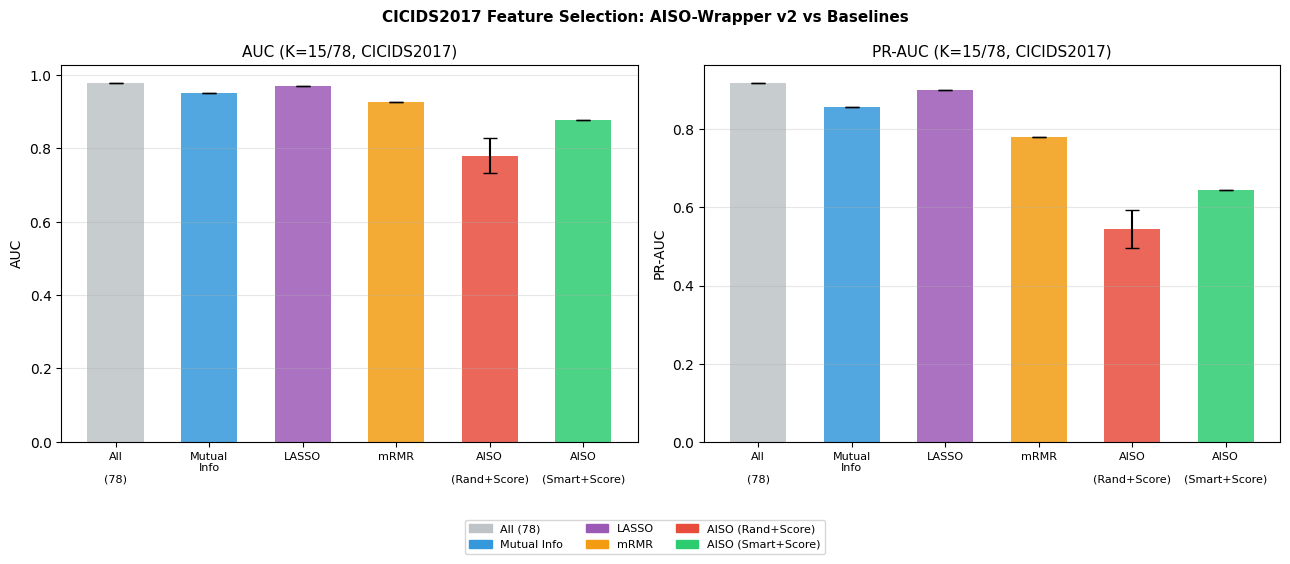

-> exp6_cicids_comparison.png 저장


In [9]:
colors_map = {
    f"All ({N_FEAT})": "#bdc3c7",
    "Mutual Info":      "#3498db",
    "LASSO":            "#9b59b6",
    "mRMR":             "#f39c12",
    "AISO (Rand+Score)": "#e74c3c",
    "AISO (Smart+Score)": "#2ecc71",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x     = np.arange(len(METHOD_ORDER))
means = [summary[m]['AUC_mean']   for m in METHOD_ORDER]
stds  = [summary[m]['AUC_std']    for m in METHOD_ORDER]
cols  = [colors_map[m]            for m in METHOD_ORDER]

axes[0].bar(x, means, yerr=stds, capsize=5, color=cols, alpha=0.85, width=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace(' ', '\n').replace('(', '\n(') for m in METHOD_ORDER], fontsize=8)
axes[0].set_ylabel("AUC")
axes[0].set_title(f"AUC (K={K_SELECT}/{N_FEAT}, CICIDS2017)", fontsize=11)
axes[0].grid(alpha=0.3, axis='y')

pr_means = [summary[m]['PRAUC_mean'] for m in METHOD_ORDER]
pr_stds  = [summary[m]['PRAUC_std']  for m in METHOD_ORDER]
axes[1].bar(x, pr_means, yerr=pr_stds, capsize=5, color=cols, alpha=0.85, width=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels([m.replace(' ', '\n').replace('(', '\n(') for m in METHOD_ORDER], fontsize=8)
axes[1].set_ylabel("PR-AUC")
axes[1].set_title(f"PR-AUC (K={K_SELECT}/{N_FEAT}, CICIDS2017)", fontsize=11)
axes[1].grid(alpha=0.3, axis='y')

patches = [mpatches.Patch(color=colors_map[m], label=m) for m in METHOD_ORDER]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=8, bbox_to_anchor=(0.5, -0.12))
plt.suptitle("CICIDS2017 Feature Selection: AISO-Wrapper v2 vs Baselines",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig("exp6_cicids_comparison.png", dpi=120, bbox_inches='tight')
plt.show()
print("-> exp6_cicids_comparison.png 저장")